In [2]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 6.6 MB/s eta 0:00:08
   - -------------------------------------- 1.6/48.9 MB 4.6 MB/s eta 0:00:11
   - -------------------------------------- 2.4/48.9 MB 4.3 MB/s eta 0:00:11
   -- ------------------------------------- 3.1/48.9 MB 4.2 MB/s eta 0:00:11
   --- ------------------------------------ 3.9/48.9 MB 4.1 MB/s eta 0:00:11
   --- ------------------------------------ 4.7/48.9 MB 4.1 MB/s eta 0:00:11
   ---- ----------------------------------- 5.5/48.9 MB 4.0 MB/s eta 0:00:11
   ----- ---------------------------------- 6.3/48.9 MB 4.0 MB/s eta 0:00:11
   ----- ---------------------------------- 7.1/48.9 MB 4.0 MB/s eta 0:00:11
   ------ --------------------------------- 7.9/48.9 MB 4.0 MB/s eta 0:00:11
   ------- -------------------------------- 8.7/48.9 MB 4.0 MB/s eta 0:00:11
   --


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import pickle

In [4]:
df = pd.read_csv("demand_forecasting.csv")

In [5]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='str')

In [10]:
feature = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]

In [11]:
feature

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [12]:
target = "Demand"

In [13]:
X = df[feature].copy()
y = df[target].copy()

In [14]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [15]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [16]:
label_encoders = {}

categorical_cols = X.select_dtypes(include=['object']).columns

C:\Users\monda\AppData\Local\Temp\ipykernel_12300\3473222035.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


In [17]:
categorical_cols

Index(['Category'], dtype='str')

In [18]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
X_train

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
42977,173.99,0,101,0,148.69,2
67352,56.38,20,492,1,65.01,3
41725,57.37,20,175,1,66.59,0
10724,92.69,5,892,0,101.09,1
56438,97.70,10,402,0,92.08,0
...,...,...,...,...,...,...
37194,58.78,10,264,0,63.10,3
6265,38.15,10,232,1,42.47,3
54886,91.77,10,56,0,102.12,3
860,14.34,5,626,0,13.33,3


In [23]:
xgb = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

In [24]:
parameter_dict = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    "min_child_weight": [1, 3, 5]
}

In [25]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=parameter_dict,
    n_iter=25,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [26]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a fu

In [27]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 200,
 'min_child_weight': 5,
 'max_depth': 8,
 'learning_rate': 0.05,
 'gamma': 0.3,
 'colsample_bytree': 1.0}

In [28]:
best_model = random_search.best_estimator_

In [31]:
y_pred = best_model.predict(X_test)
y_pred

array([ 81.68219 ,  70.209435,  36.62561 , ...,  74.9266  ,  64.182396,
       108.59041 ], shape=(15200,), dtype=float32)

In [32]:
y_test

53731    111
61112     81
72074     37
56928    152
20979    101
        ... 
44505    149
21165    106
11310     31
48677     21
57438    157
Name: Demand, Length: 15200, dtype: int64

In [37]:
mean_squared_error(y_test, y_pred)**0.5 # RMSE

35.50381664122535

In [38]:
best_model.feature_importances_

array([0.07301962, 0.02104159, 0.02018695, 0.58445024, 0.02429584,
       0.27700576], dtype=float32)

In [39]:
feature_importance = pd.Series(
    best_model.feature_importances_, 
    index=X.columns
    ).sort_values(ascending=False)

In [40]:
feature_importance

Promotion             0.584450
Category              0.277006
Price                 0.073020
Competitor Pricing    0.024296
Discount              0.021042
Inventory Level       0.020187
dtype: float32

<Axes: title={'center': 'Feature Importance'}>

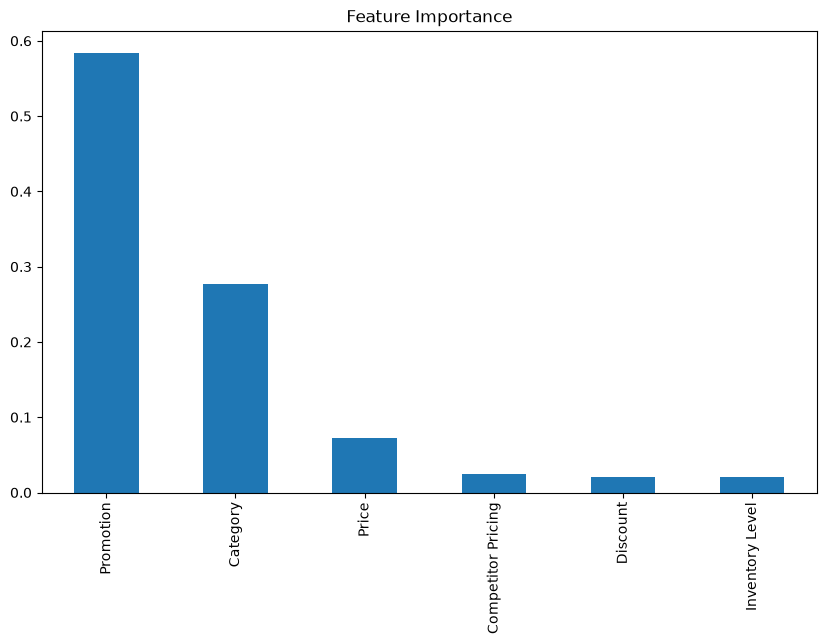

In [41]:
feature_importance.plot(kind='bar', figsize=(10, 6), title='Feature Importance')

In [51]:
from pathlib import Path

project_folder = Path(
    r"C:\Users\monda\OneDrive - Indian Institute of Science\PythonForML\Demand Forecasting"
)

project_folder.mkdir(parents=True, exist_ok=True)

print("Folder exists:", project_folder.exists())

Folder exists: True


In [52]:
with open(project_folder / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

In [54]:
with open(project_folder / "Xgboost_demand_model.pkl", 'wb') as f:
    pickle.dump(best_model, f)